<a href="https://colab.research.google.com/github/farrelrassya/IntroductionMachineLearningwithpython/blob/main/Practical%20Linear%20Algebra%20for%20Data%20Science/10.Row_Reduction_and_LU_Decomposition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bab 10 - Reduksi Baris dan Dekomposisi LU (Row Reduction and LU Decomposition)

Notebook ini membahas sistem persamaan linier, eliminasi Gauss-Jordan, bentuk eselon baris tereduksi (RREF), serta dekomposisi LU (Lower-Upper) untuk efisiensi komputasi.

### Identitas Mahasiswa
| Detail | Identitas |
| :--- | :--- |
| **Nama** | Rahmanda Afebrio Yuris Soesatyo |
| **NIM** | 1103223024 |


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# sympy library for RREF
import sympy as sym

# scipy for LU
import scipy.linalg


# used to create non-regular subplots
import matplotlib.gridspec as gridspec


# NOTE: these lines define global figure properties used for publication.
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg') # display figures in vector format
plt.rcParams.update({'font.size':14}) # set global font size

# Bekerja dengan Persamaan Matriks


In [2]:
# generate some matrices
A = np.random.randn(4,4)
B = np.random.randn(4,4)

# solve for X
# 1) inv(A)@A@X = inv(A)@B
# 2) inv(A)@A@X = B@inv(A)

X1 = np.linalg.inv(A) @ B
X2 = B @ np.linalg.inv(A)

# residual (should be zeros matrix)
res1 = A@X1 - B
res2 = A@X2 - B

# which is correct?
print('res1:'), print(' ')
print( np.round(res1,10) ), print(' ')

print('res2:'), print(' ')
print( np.round(res2,10) )


res1:
 
[[-0. -0.  0.  0.]
 [-0.  0.  0.  0.]
 [ 0. -0. -0.  0.]
 [ 0.  0. -0.  0.]]
 
res2:
 
[[-19.78931846  11.60501676 -13.31283123 -26.11931479]
 [-10.25767464   5.97695487  -5.3616902  -11.78557668]
 [-76.01020914  34.29672063 -56.05163416 -97.87201255]
 [ 53.51256218 -21.20174698  38.27190575  69.86399775]]


# Bentuk Eselon Baris Tereduksi (RREF)


In [3]:
# the augmented matrix
M = np.array([ [1,1,4],[-1/2,1,2] ])

# converted into a sympy matrix
symMat = sym.Matrix(M)
print(symMat)

# RREF
symMat.rref()[0] # just the first output to get the RREF matrix (the second output is the indices of the pivots per row)

Matrix([[1.00000000000000, 1.00000000000000, 4.00000000000000], [-0.500000000000000, 1.00000000000000, 2.00000000000000]])


Matrix([
[1, 0, 1.33333333333333],
[0, 1, 2.66666666666667]])

# Dekomposisi LU (Lower-Upper)


In [4]:
# simple example with integers

# a matrix
A = np.array([ [2,2,4], [1,0,3], [2,1,2] ])

# its LU decomposition via scipy (please ignore the first output for now)
_,L,U = scipy.linalg.lu(A)

# print them out
print('L: ')
print(L), print(' ')

print('U: ')
print(U), print(' ')

print('A - LU: ')
print(A - L@U) # should be zeros

L: 
[[1.  0.  0. ]
 [0.5 1.  0. ]
 [1.  1.  1. ]]
 
U: 
[[ 2.  2.  4.]
 [ 0. -1.  1.]
 [ 0.  0. -3.]]
 
A - LU: 
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


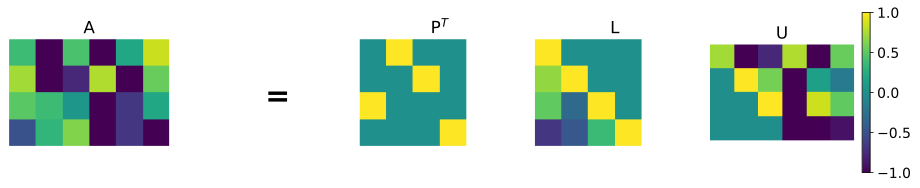

In [5]:
# matrix sizes
m = 4
n = 6

A = np.random.randn(m,n)

P,L,U = scipy.linalg.lu(A)

# show the matrices
fig,axs = plt.subplots(1,5,figsize=(13,4))

axs[0].imshow(A,vmin=-1,vmax=1)
axs[0].set_title('A')

axs[1].imshow(np.ones((m,n)),cmap='gray',vmin=-1,vmax=1)
axs[1].text(n/2,m/2,'=',ha='center',fontsize=30,fontweight='bold')
# axs[1].axis('off')

axs[2].imshow(P.T,vmin=-1,vmax=1)
axs[2].set_title(r'P$^T$')

axs[3].imshow(L,vmin=-1,vmax=1)
axs[3].set_title('L')

h = axs[4].imshow(U,vmin=-1,vmax=1)
axs[4].set_title('U')

for a in axs:
  a.axis('off')
  a.set_xlim([-.5,n-.5])
  a.set_ylim([m-.5,-.5])


fig.colorbar(h,ax=axs[-1],fraction=.05)
plt.tight_layout()
plt.savefig('Figure_10_01.png',dpi=300)
plt.show()

# Latihan 1

In [6]:
# Time-test!

import time

# start the timer
tic = time.time()

# run the test
for i in range(1000):
  A = np.random.randn(100,100)
  P,L,U = scipy.linalg.lu(A)

# stop the timer
toc = time.time() - tic
toc # print the result in seconds

0.31067728996276855

# Latihan 2

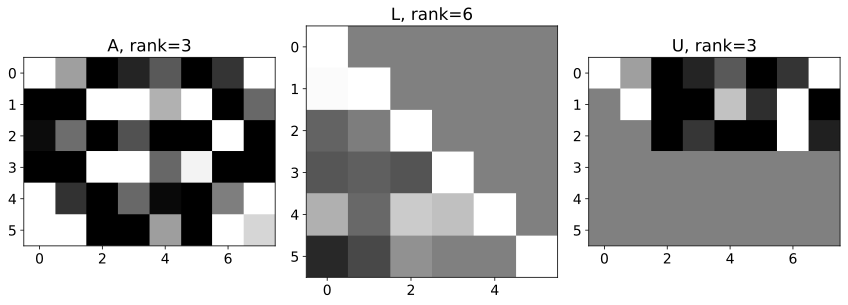

In [7]:
# make a reduced-rank random matrix

# sizes and rank
M = 6
N = 8
r = 3

# create the matrix
A = np.random.randn(M,r) @ np.random.randn(r,N)

# LU
P,L,U = scipy.linalg.lu(A)

# and plot
_,axs = plt.subplots(1,3,figsize=(12,7))

axs[0].imshow(A,vmin=-1,vmax=1,cmap='gray')
axs[0].set_title(f'A, rank={np.linalg.matrix_rank(A)}')

axs[1].imshow(L,vmin=-1,vmax=1,cmap='gray')
axs[1].set_title(f'L, rank={np.linalg.matrix_rank(L)}')

axs[2].imshow(U,vmin=-1,vmax=1,cmap='gray')
axs[2].set_title(f'U, rank={np.linalg.matrix_rank(U)}')

plt.tight_layout()
plt.savefig('Figure_10_02.png',dpi=300)
plt.show()

In [8]:
np.round(L,2)

array([[ 1.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ],
       [ 0.96,  1.  ,  0.  ,  0.  ,  0.  ,  0.  ],
       [-0.23, -0.02,  1.  ,  0.  ,  0.  ,  0.  ],
       [-0.33, -0.25, -0.34,  1.  ,  0.  ,  0.  ],
       [ 0.38, -0.18,  0.59,  0.5 ,  1.  ,  0.  ],
       [-0.68, -0.43,  0.14, -0.  ,  0.  ,  1.  ]])

# Latihan 3

In [9]:
# a matrix and its det
M = 6
A = np.random.randn(M,M)

# LU
P,L,U = scipy.linalg.lu(A)

# determinant as the product of the diagonals of U
detLU = np.prod( np.diag(U) ) * np.linalg.det(P)

# check against the det function
detNP = np.linalg.det(A)

# compare
print(detLU,detNP)
print(detLU-detNP)

-3.49927220515612 -3.499272205156121
8.881784197001252e-16


# Latihan 4

In [10]:
# matrix sizes
m = 4
A = np.random.randn(m,m)

# LU decomposition
P,L,U = scipy.linalg.lu(A)

# inverse
invViaLU = np.linalg.inv(U) @ np.linalg.inv(L) @ P.T

# "regular" inverse
invViaInv = np.linalg.inv(A)

np.round( A@invViaLU ,10)

array([[ 1.,  0., -0., -0.],
       [-0.,  1., -0.,  0.],
       [ 0.,  0.,  1.,  0.],
       [-0., -0.,  0.,  1.]])

# Latihan 5

In [11]:
# The reason is that writing out the equation leads to PtP in the middle, which is the identity matrix. 
# Conceptually, it means that any row swaps are undone when multiplying by the transpose.

# create a matrix
A = np.random.randn(4,4)

# LUP
P,L,U = scipy.linalg.lu(A)

# compute AtA via LU
AtA_lu = U.T @ L.T @ L @ U

# direct computation
AtA_direct = A.T @ A

# compare to direct computation
np.round( AtA_lu - AtA_direct ,10)

array([[ 0.,  0.,  0., -0.],
       [-0.,  0.,  0.,  0.],
       [ 0., -0.,  0., -0.],
       [-0.,  0., -0., -0.]])

---

## Ringkasan dan Pandangan (Summary and Outlook)

### Ringkasan Bab 10

Kita telah mempelajari bagaimana bentuk RREF diperoleh melalui operasi baris elementer dan bagaimana dekomposisi LU membagi matriks menjadi bagian segitiga bawah L dan segitiga atas U untuk mempercepat pencarian solusi persamaan linier berulang.

### Pandangan ke Depan

Pada Bab 11, kita akan mengintegrasikan sistem persamaan linier ini ke dalam model regresi least squares untuk memprediksi data numerik.
